# SimCLR Contrastive Training for Human Activity Recognition Tutorial

In [1]:
# Author: C. I. Tang
# Based on work of Tang et al.: https://arxiv.org/abs/2011.11542
# Contact: cit27@cl.cam.ac.uk
# License: GNU General Public License v3.0

%load_ext autoreload
%autoreload 2

## Imports

In [2]:
import os
import pickle
import scipy
import datetime
import numpy as np
import tensorflow as tf

seed = 1
tf.random.set_seed(seed)
np.random.seed(seed)

I0000 00:00:1774281733.137135 2445475 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774281733.137821 2445475 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774281733.197355 2445475 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1774281735.500881 2445475 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774281735.501286 2445475 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
# Libraries for plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.manifold

sns.set_context('poster')

In [4]:
# Library scripts
import raw_data_processing
import data_pre_processing
import simclr_models
import simclr_utitlities
import transformations

In [5]:
working_directory = 'test_run/'
dataset_save_path = working_directory
if not os.path.exists(working_directory):
    os.mkdir(working_directory)


## MotionSense Dataset

In this section, the MotionSense dataset will be downloaded and parsed. The results will then be saved in a python pickle file.
(Note: This section only needs to be run once)

Citation:
```
@inproceedings{Malekzadeh:2019:MSD:3302505.3310068,
author = {Malekzadeh, Mohammad and Clegg, Richard G. and Cavallaro, Andrea and Haddadi, Hamed},
title = {Mobile Sensor Data Anonymization},
booktitle = {Proceedings of the International Conference on Internet of Things Design and Implementation},
series = {IoTDI '19},
year = {2019},
isbn = {978-1-4503-6283-2},
location = {Montreal, Quebec, Canada},
pages = {49--58},
numpages = {10},
url = {http://doi.acm.org/10.1145/3302505.3310068},
doi = {10.1145/3302505.3310068},
acmid = {3310068},
publisher = {ACM},
address = {New York, NY, USA},
keywords = {adversarial training, deep learning, edge computing, sensor data privacy, time series analysis},
} 
```

### Downloading & Unzipping

In [6]:
import requests
import zipfile

In [7]:
dataset_url = 'https://github.com/mmalekzadeh/motion-sense/blob/master/data/B_Accelerometer_data.zip?raw=true'

r = requests.get(dataset_url, allow_redirects=True)
with open(working_directory + 'B_Accelerometer_data.zip', 'wb') as f:
    f.write(r.content)

In [8]:

with zipfile.ZipFile(working_directory + 'B_Accelerometer_data.zip', 'r') as zip_ref:
    zip_ref.extractall(working_directory)

### Data Processing

In [9]:
accelerometer_data_folder_path = working_directory + 'B_Accelerometer_data/'
user_datasets = raw_data_processing.process_motion_sense_accelerometer_files(accelerometer_data_folder_path)

test_run/B_Accelerometer_data/dws_1
test_run/B_Accelerometer_data/dws_11
test_run/B_Accelerometer_data/dws_2
test_run/B_Accelerometer_data/jog_16


test_run/B_Accelerometer_data/jog_9
test_run/B_Accelerometer_data/sit_13
test_run/B_Accelerometer_data/sit_5


test_run/B_Accelerometer_data/std_14
test_run/B_Accelerometer_data/std_6


test_run/B_Accelerometer_data/ups_12
test_run/B_Accelerometer_data/ups_3
test_run/B_Accelerometer_data/ups_4
test_run/B_Accelerometer_data/wlk_15


test_run/B_Accelerometer_data/wlk_7
test_run/B_Accelerometer_data/wlk_8


In [10]:
with open(working_directory + 'motion_sense_user_split.pkl', 'wb') as f:
    pickle.dump({
        'user_split': user_datasets,
    }, f)

## Pre-processing

In [11]:
# Parameters
window_size = 400
input_shape = (window_size, 3)

# Dataset Metadata 
transformation_multiple = 1
dataset_name = 'motion_sense.pkl'
dataset_name_user_split = 'motion_sense_user_split.pkl'

label_list = ['null', 'sit', 'std', 'wlk', 'ups', 'dws', 'jog']
label_list_full_name = ['null', 'sitting', 'standing', 'walking', 'walking upstairs', 'walking downstairs', 'jogging']
has_null_class = True

label_map = dict([(l, i) for i, l in enumerate(label_list)])

output_shape = len(label_list)

model_save_name = f"motionsense_acc"

sampling_rate = 50.0
unit_conversion = scipy.constants.g

# a fixed user-split
test_users_fixed = [1, 14, 19, 23, 6]
def get_fixed_split_users(har_users):
    # test_users = har_users[0::5]
    test_users = test_users_fixed
    train_users = [u for u in har_users if u not in test_users]
    return (train_users, test_users)

In [12]:
with open(dataset_save_path + dataset_name_user_split, 'rb') as f:
    dataset_dict = pickle.load(f)
    user_datasets = dataset_dict['user_split']


In [13]:
har_users = list(user_datasets.keys())
train_users, test_users = get_fixed_split_users(har_users)
print(f'Testing: {test_users}, Training: {train_users}')

Testing: [1, 14, 19, 23, 6], Training: [10, 11, 12, 13, 15, 16, 17, 18, 2, 20, 21, 22, 24, 3, 4, 5, 7, 8, 9]


Here we convert the original dataset into a windowed one, and split it into training, validation and testing sets. 

In [14]:
np_train, np_val, np_test = data_pre_processing.pre_process_dataset_composite(
    user_datasets=user_datasets, 
    label_map=label_map, 
    output_shape=output_shape, 
    train_users=train_users, 
    test_users=test_users, 
    window_size=window_size, 
    shift=window_size//2, 
    normalise_dataset=True, 
    verbose=1
)



Test
(array(['dws', 'jog', 'sit', 'std', 'ups', 'wlk'], dtype='<U3'), array([112, 133, 360, 335, 148, 331]))
(array([1, 2, 3, 4, 5, 6]), array([360, 335, 331, 148, 112, 133]))
-----------------
Train
(array(['dws', 'jog', 'sit', 'std', 'ups', 'wlk'], dtype='<U3'), array([ 449,  480, 1282, 1146,  546, 1308]))
(array([1, 2, 3, 4, 5, 6]), array([1282, 1146, 1308,  546,  449,  480]))
-----------------
Training data shape: (4168, 400, 3)
Validation data shape: (1043, 400, 3)
Testing data shape: (1419, 400, 3)


An alternative processing pipeline can be used to retain the user id as a feature and/or a label in the output dataset.

Note: This is not used in the study, and thus is commented in this notebook.

In [15]:
# user_datasets_processed = data_pre_processing.pre_process_dataset_composite_in_user_format(
#     user_datasets=user_datasets, 
#     label_map=label_map, 
#     output_shape=output_shape, 
#     train_users=train_users, 
#     window_size=window_size, 
#     shift=window_size//2, 
#     normalise_dataset=True, 
#     verbose=1
# )

# user_datasets_with_user_ids, user_id_mapping = data_pre_processing.add_user_id_to_windowed_dataset(
#     user_datasets_processed, 
#     encode_user_id=True, 
#     as_feature=True, 
#     as_label=False, 
#     verbose=1
# )

# train_x, train_y, test_x, test_y = data_pre_processing.combine_windowed_dataset(user_datasets_with_user_ids, train_users)
# train_x_split, val_x_split, train_y_split, val_y_split = sklearn.model_selection.train_test_split(train_x, train_y, test_size=0.2, random_state=42)

# np_train = (train_x_split, train_y_split)
# np_val = (val_x_split, val_y_split)
# np_test = (test_x, test_y)

# print("Training data shape:", train_x_split.shape)
# print("Validation data shape:", val_x_split.shape)
# print("Testing data shape:", test_x.shape)

## SimCLR Training

In [16]:
batch_size = 512
decay_steps = 1000
epochs = 200
temperature = 0.1
transform_funcs = [
    # transformations.scaling_transform_vectorized, # Use Scaling trasnformation
    transformations.rotation_transform_vectorized # Use rotation trasnformation
]
transformation_function = simclr_utitlities.generate_composite_transform_function_simple(transform_funcs)

# trasnformation_indices = [2] # Use rotation trasnformation only
# trasnformation_indices = [1, 2] # Use Scaling and rotation trasnformation

# trasnform_funcs_vectorized = [
#     transformations.noise_transform_vectorized, 
#     transformations.scaling_transform_vectorized, 
#     transformations.rotation_transform_vectorized, 
#     transformations.negate_transform_vectorized, 
#     transformations.time_flip_transform_vectorized, 
#     transformations.time_segment_permutation_transform_improved, 
#     transformations.time_warp_transform_low_cost, 
#     transformations.channel_shuffle_transform_vectorized
# ]
# transform_funcs_names = ['noised', 'scaled', 'rotated', 'negated', 'time_flipped', 'permuted', 'time_warped', 'channel_shuffled']



0 <function rotation_transform_vectorized at 0x7f45beb91c60>


In [17]:
start_time = datetime.datetime.now()
start_time_str = start_time.strftime("%Y%m%d-%H%M%S")
tf.keras.backend.set_floatx('float32')

lr_decayed_fn = tf.keras.optimizers.schedules.CosineDecay(initial_learning_rate=0.1, decay_steps=decay_steps)
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_decayed_fn)
# transformation_function = simclr_utitlities.generate_combined_transform_function(trasnform_funcs_vectorized, indices=trasnformation_indices)

base_model = simclr_models.create_base_model(input_shape, model_name="base_model")
simclr_model = simclr_models.attach_simclr_head(base_model)
simclr_model.summary()

trained_simclr_model, epoch_losses = simclr_utitlities.simclr_train_model(simclr_model, np_train[0], optimizer, batch_size, transformation_function, temperature=temperature, epochs=epochs, is_trasnform_function_vectorized=True, verbose=1)

simclr_model_save_path = f"{working_directory}{start_time_str}_simclr.keras"
trained_simclr_model.save(simclr_model_save_path)



E0000 00:00:1774282266.702844 2445475 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "base_model_simclr"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 400, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 377, 32)        │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 377, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 362, 64)        │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 362, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 355, 96)        │        49,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 355, 96)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 96)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         6,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,594 (580.45 KB)

 Trainable params: 148,594 (580.45 KB)

...

epoch: 196 loss: 3.198


epoch: 197 loss: 3.130


epoch: 198 loss: 3.197


epoch: 199 loss: 3.161


epoch: 200 loss: 3.184


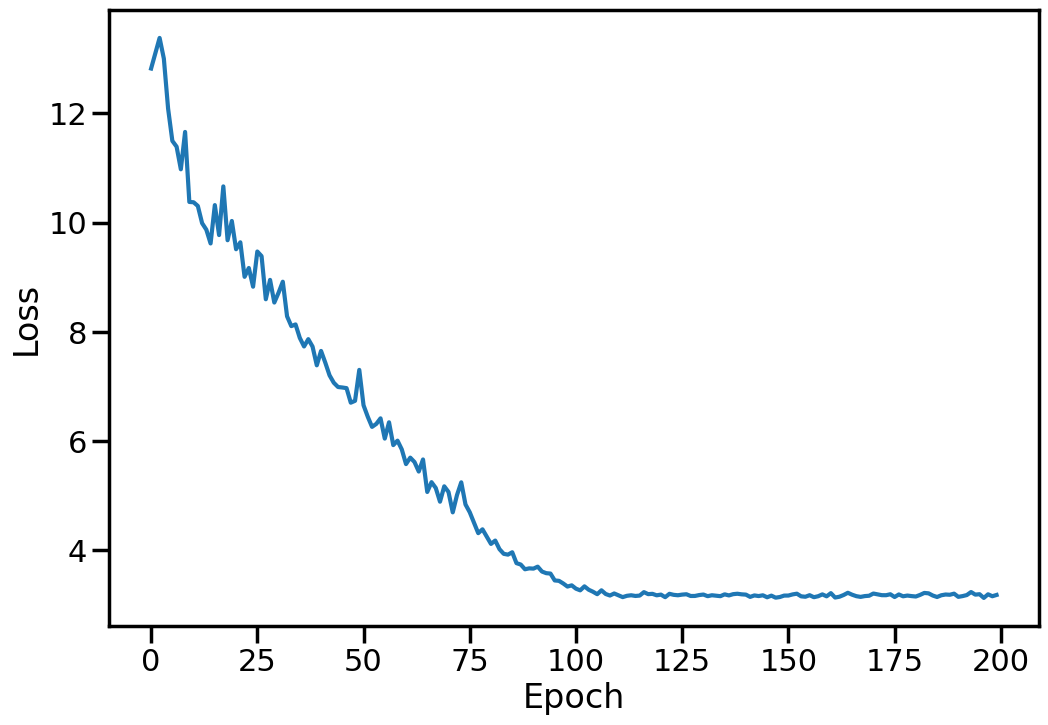

In [18]:
plt.figure(figsize=(12,8))
plt.plot(epoch_losses)
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

## Fine-tuning and Evaluation

### Linear Model

In [19]:

total_epochs = 50
batch_size = 200
tag = "linear_eval"

simclr_model = tf.keras.models.load_model(simclr_model_save_path)
linear_evaluation_model = simclr_models.create_linear_model_from_base_model(simclr_model, output_shape, intermediate_layer=7)

linear_eval_best_model_file_name = f"{working_directory}{start_time_str}_simclr_{tag}.keras"
best_model_callback = tf.keras.callbacks.ModelCheckpoint(linear_eval_best_model_file_name,
    monitor='val_loss', mode='min', save_best_only=True, save_weights_only=False, verbose=0
)

training_history = linear_evaluation_model.fit(
    x = np_train[0],
    y = np_train[1],
    batch_size=batch_size,
    shuffle=True,
    epochs=total_epochs,
    callbacks=[best_model_callback],
    validation_data=np_val
)

linear_eval_best_model = tf.keras.models.load_model(linear_eval_best_model_file_name)

print("Model with lowest validation Loss:")
print(simclr_utitlities.evaluate_model_simple(linear_eval_best_model.predict(np_test[0]), np_test[1], return_dict=True))
print("Model in last epoch")
print(simclr_utitlities.evaluate_model_simple(linear_evaluation_model.predict(np_test[0]), np_test[1], return_dict=True))


Epoch 1/50


 1/21 ━━━━━━━━━━━━━━━━━━━━ 13s 654ms/step - auc: 0.3942 - categorical_accuracy: 0.0250 - loss: 1.9935 - precision: 0.0000e+00 - recall: 0.0000e+00

 2/21 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - auc: 0.5154 - categorical_accuracy: 0.1363 - loss: 1.8896 - precision: 0.2941 - recall: 0.0625         

 3/21 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - auc: 0.5852 - categorical_accuracy: 0.1975 - loss: 1.8035 - precision: 0.4072 - recall: 0.0839

 4/21 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - auc: 0.6297 - categorical_accuracy: 0.2378 - loss: 1.7403 - precision: 0.4612 - recall: 0.1048

...

34/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

40/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


{'Confusion Matrix': array([[360,   0,   0,   0,   0,   0],
       [115, 220,   0,   0,   0,   0],
       [  1,   0, 327,   1,   0,   2],
       [  2,   5,   5, 134,   2,   0],
       [  1,   0,  98,  11,   2,   0],
       [  0,   0,   5,   1,   0, 127]]), 'F1 Macro': 0.7350146086283399, 'F1 Micro': 0.8245243128964059, 'F1 Weighted': 0.7907060393052451, 'Precision': 0.8128547379323893, 'Recall': 0.7537969320121823, 'Kappa': 0.7767119565217392}


### Full HAR Model

In [20]:

total_epochs = 50
batch_size = 200
tag = "full_eval"

simclr_model = tf.keras.models.load_model(simclr_model_save_path)
full_evaluation_model = simclr_models.create_full_classification_model_from_base_model(simclr_model, output_shape, model_name="TPN", intermediate_layer=7, last_freeze_layer=4)

full_eval_best_model_file_name = f"{working_directory}{start_time_str}_simclr_{tag}.keras"
best_model_callback = tf.keras.callbacks.ModelCheckpoint(full_eval_best_model_file_name,
    monitor='val_loss', mode='min', save_best_only=True, save_weights_only=False, verbose=0
)

training_history = full_evaluation_model.fit(
    x = np_train[0],
    y = np_train[1],
    batch_size=batch_size,
    shuffle=True,
    epochs=total_epochs,
    callbacks=[best_model_callback],
    validation_data=np_val
)

full_eval_best_model = tf.keras.models.load_model(full_eval_best_model_file_name)

print("Model with lowest validation Loss:")
print(simclr_utitlities.evaluate_model_simple(full_eval_best_model.predict(np_test[0]), np_test[1], return_dict=True))
print("Model in last epoch")
print(simclr_utitlities.evaluate_model_simple(full_evaluation_model.predict(np_test[0]), np_test[1], return_dict=True))


Epoch 1/50


 1/21 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - auc: 0.4860 - categorical_accuracy: 0.1150 - loss: 2.5858 - precision: 0.0000e+00 - recall: 0.0000e+00

 2/21 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step - auc: 0.5539 - categorical_accuracy: 0.1525 - loss: 2.3684 - precision: 0.0880 - recall: 0.0237      

 3/21 ━━━━━━━━━━━━━━━━━━━━ 2s 166ms/step - auc: 0.6110 - categorical_accuracy: 0.1983 - loss: 2.1849 - precision: 0.2053 - recall: 0.0647

 4/21 ━━━━━━━━━━━━━━━━━━━━ 2s 165ms/step - auc: 0.6539 - categorical_accuracy: 0.2441 - loss: 2.0434 - precision: 0.2942 - recall: 0.1017

...

38/45 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

44/45 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


{'Confusion Matrix': array([[360,   0,   0,   0,   0,   0],
       [ 63, 271,   0,   0,   1,   0],
       [  0,   0, 248,  32,  48,   3],
       [  1,   0,   0, 135,  12,   0],
       [  9,   0,   7,   3,  92,   1],
       [  0,   0,   0,   2,   0, 131]]), 'F1 Macro': 0.8607419831063939, 'F1 Micro': 0.8717406624383368, 'F1 Weighted': 0.873366973634978, 'Precision': 0.8600865127387424, 'Recall': 0.8794588460795508, 'Kappa': 0.840772554416182}


## Extra: t-SNE Plots

### Parameters

In [21]:
# Select a model from which the intermediate representations are extracted
target_model = simclr_model 
perplexity = 30.0


### t-SNE Representations

In [22]:
intermediate_model = simclr_models.extract_intermediate_model_from_base_model(target_model, intermediate_layer=7)
intermediate_model.summary()

embeddings = intermediate_model.predict(np_test[0], batch_size=600)
tsne_model = sklearn.manifold.TSNE(perplexity=perplexity, verbose=1, random_state=42)
tsne_projections = tsne_model.fit_transform(embeddings)



Model: "base_model_simclr_layer_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 400, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 377, 32)        │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 377, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 362, 64)        │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 362, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 355, 96)        │        49,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 355, 96)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 96)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,416 (329.75 KB)

 Trainable params: 49,248 (192.38 KB)

 Non-trainable params: 35,168 (137.38 KB)

...

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1419 samples in 0.001s...


[t-SNE] Computed neighbors for 1419 samples in 0.055s...


[t-SNE] Computed conditional probabilities for sample 1000 / 1419
[t-SNE] Computed conditional probabilities for sample 1419 / 1419
[t-SNE] Mean sigma: 0.345032


[t-SNE] KL divergence after 250 iterations with early exaggeration: 51.115295


[t-SNE] KL divergence after 1000 iterations: 0.228471


### Plotting

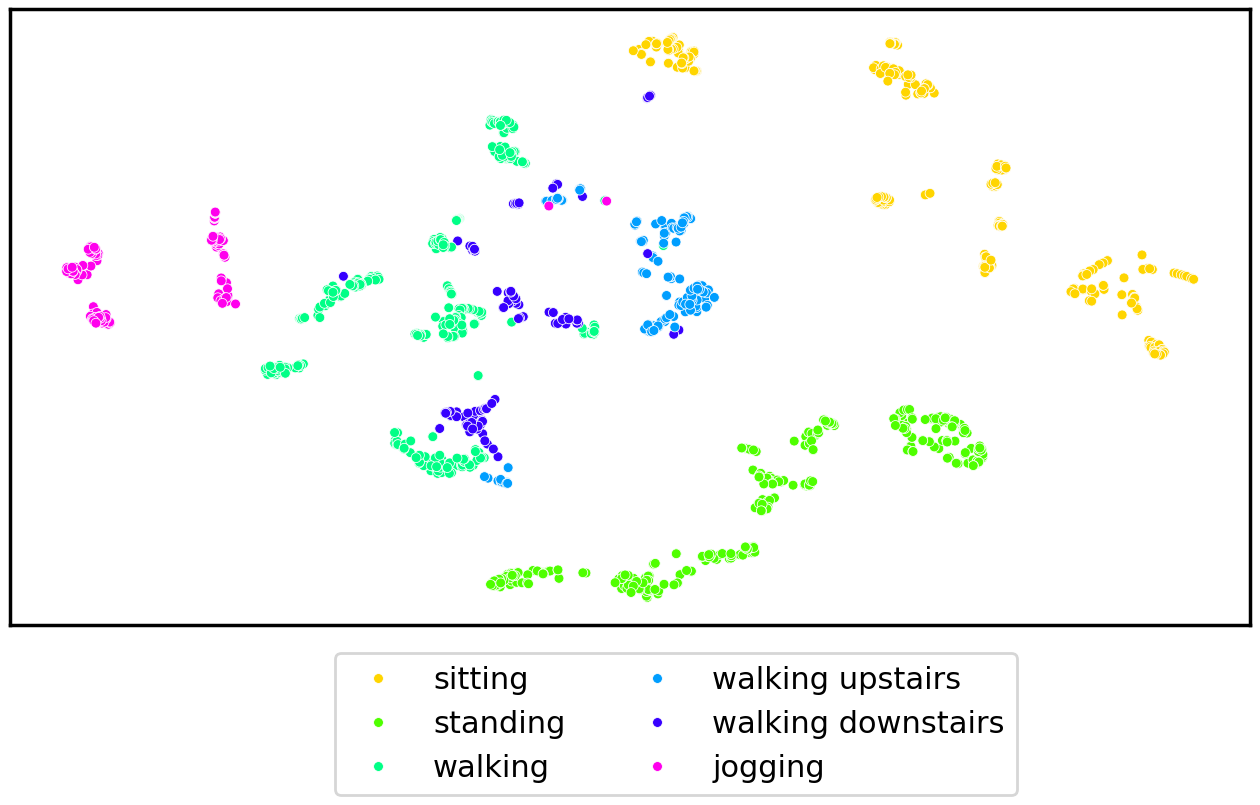

In [23]:
labels_argmax = np.argmax(np_test[1], axis=1)
unique_labels = np.unique(labels_argmax)

plt.figure(figsize=(16,8))
graph = sns.scatterplot(
    x=tsne_projections[:,0], y=tsne_projections[:,1],
    hue=labels_argmax,
    palette=sns.color_palette("hsv", len(unique_labels)),
    s=50,
    alpha=1.0,
    rasterized=True
)
plt.xticks([], [])
plt.yticks([], [])


plt.legend(loc='lower left', bbox_to_anchor=(0.25, -0.3), ncol=2)
legend = graph.legend_
for j, label in enumerate(unique_labels):
    legend.get_texts()[j].set_text(label_list_full_name[label]) 

### Custom Color maps (Optional)

This section can be run to produce plots where semantically similar classes share similar colors. This requires the definition of a custom mapping of classes to colors.

In [24]:
# This is used to select colors for labels which are close to each other
# Each pair corresponds to one label class
# i.e. ['null', 'sitting', 'standing', 'walking', 'walking upstairs', 'walking downstairs', 'jogging']
# The first number determines the color map, and the second determines its value along the color map
# So 'sitting', 'standing' will share similar colors, and 'walking', 'walking upstairs', 'walking downstairs' will share another set of similar colors
label_color_spectrum = [(0, 0), (1, 0), (1, 1), (2, 0), (2, 1), (2, 2), (3, 0)] 

# This step generates a list of colors for different categories of activities
# Here we assume 5 categories, and 5 different intesities within each category
major_colors = ['cool', 'Blues', 'Greens', 'Oranges', 'Purples']
color_map_base = dict (
    [((i, j), color) for i, major_color in enumerate(major_colors) for j, color in enumerate(reversed(sns.color_palette(major_color, 5))) ]
)
color_palette = np.array([color_map_base[color_index] for color_index in label_color_spectrum])

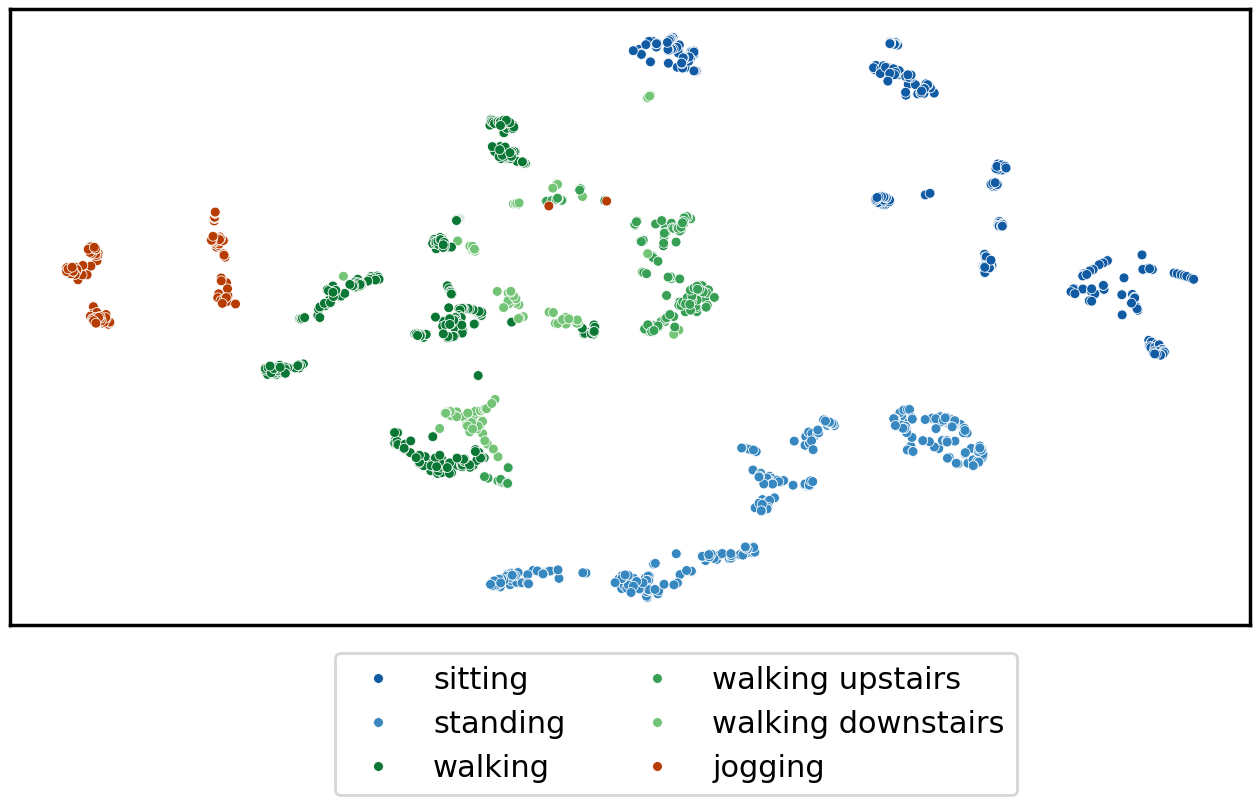

In [25]:
# This selects the appropriate number of colors to be used in the plot
labels_argmax = np.argmax(np_test[1], axis=1)
unique_labels = np.unique(labels_argmax)

plt.figure(figsize=(16,8))
graph = sns.scatterplot(
    x=tsne_projections[:,0], y=tsne_projections[:,1],
    hue=labels_argmax,
    palette=list(color_palette[unique_labels]),
    s=50,
    alpha=1.0,
    rasterized=True
)
plt.xticks([], [])
plt.yticks([], [])


plt.legend(loc='lower left', bbox_to_anchor=(0.25, -0.3), ncol=2)
legend = graph.legend_
for j, label in enumerate(unique_labels):
    legend.get_texts()[j].set_text(label_list_full_name[label]) 
